# Does Team Strength Affect Home Advantage?
## The objective of this analysis is to investigate whether stronger football teams tend to have a higher home advantage.

Team strength will be measured using:
- points per game;
- goal difference;
- win rate.

Home advantage represents the difference between a team's home and away performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Data loading

In [2]:
team_stats = pd.read_csv("team_stats.csv")

## Data preparation and metric definitions
Each row represents one club in one season.

The original dataset does not contain all the metrics required for this analysis, so several additional variables will be calculated:

- points;
- points per game;
- win rate;
- goal difference;
- goal difference per game.

In [3]:
analysis_df = team_stats.copy()

In [4]:
analysis_df["MP"] = analysis_df["W"] + analysis_df["L"] + analysis_df["D"]

In [5]:
analysis_df["points"] = analysis_df["W_home"] * 3 + analysis_df["W_away"] * 3 + analysis_df["D_home"] + analysis_df["D_away"]

In [6]:
analysis_df["points_per_game"] = analysis_df["points"] / analysis_df["MP"]

In [7]:
analysis_df["goal_difference"] = analysis_df["GF"] - analysis_df["GA"]

In [8]:
analysis_df["goal_difference_per_game"] = analysis_df["goal_difference"] / analysis_df["MP"]

In [9]:
analysis_df["win_rate"] = (analysis_df["W_home"] + analysis_df["W_away"]) / analysis_df["MP"]

## Hypothesis

The purpose of this analysis is to investigate whether stronger football teams tend to have higher or lower home advantage.

To estimate team strength, we will use:
- points per game;
- win rate;
- goal difference per game.

We will begin by examining the correlations between these variables.

In [10]:
correlation_df = analysis_df[
    [
        "home_advantage",
        "points_per_game",
        "goal_difference_per_game",
        "win_rate"
    ]]

In [11]:
correlation_df.corr()

,home_advantage,points_per_game,goal_difference_per_game,win_rate
home_advantage,1.000000,0.107986,0.103916,0.124207
points_per_game,0.107986,1.000000,0.959952,0.986126
goal_difference_per_game,0.103916,0.959952,1.000000,0.936642
win_rate,0.124207,0.986126,0.936642,1.000000


<Axes: title={'center': 'points_per_game vs home_advantage'}, xlabel='points_per_game', ylabel='home_advantage'>

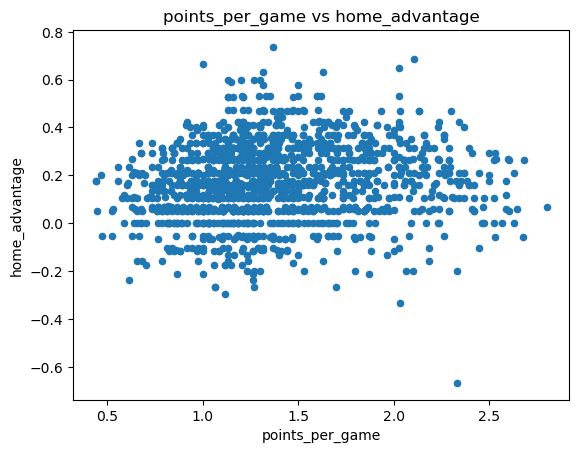

In [12]:
analysis_df.plot.scatter(x = 'points_per_game', y = 'home_advantage', title='points_per_game vs home_advantage')

### Club-level analysis

The previous analysis used one observation for each club-season. However, individual seasons may contain unusually strong or weak performances that add noise to the relationship.

To reduce the influence of single-season fluctuations, we will repeat the analysis using each club's average values across all available seasons.

In this section, one row will represent one club. We will compare the club's average home advantage with its average points per game. But only for the teams that spent 4+ seasons in leagues

In [13]:
four_seasons = (analysis_df['Club'].value_counts()>=4)

In [14]:
four_seasons = four_seasons[four_seasons == True]

In [15]:
club_analysis = analysis_df[
    [
        "Club",
        "home_advantage",
        "points_per_game",
        "goal_difference_per_game",
        "win_rate"
    ]
]

In [16]:
club_analysis = (
    club_analysis
    .groupby("Club")
    .mean()
    .reset_index()
)

In [17]:
analysis_df_filtered = club_analysis[club_analysis["Club"].isin(four_seasons.index)]

In [18]:
analysis_df_filtered.head()

,Club,home_advantage,points_per_game,goal_difference_per_game,win_rate
1,1. FC Köln,0.039216,1.147059,-0.416667,0.294118
2,1. FC Nürnberg,0.129412,1.117647,-0.447059,0.288235
3,1. FSV Mainz 05,0.184874,1.382353,0.004202,0.369748
7,ADO Den Haag,0.154412,1.143382,-0.375000,0.290441
8,AJ Auxerre,0.118421,1.375000,0.039474,0.348684


In [19]:
analysis_df_filtered.corr(numeric_only=True)

,home_advantage,points_per_game,goal_difference_per_game,win_rate
home_advantage,1.000000,0.156852,0.140350,0.168034
points_per_game,0.156852,1.000000,0.988383,0.995466
goal_difference_per_game,0.140350,0.988383,1.000000,0.981070
win_rate,0.168034,0.995466,0.981070,1.000000


<Axes: title={'center': 'points_per_game vs home_advantage'}, xlabel='points_per_game', ylabel='home_advantage'>

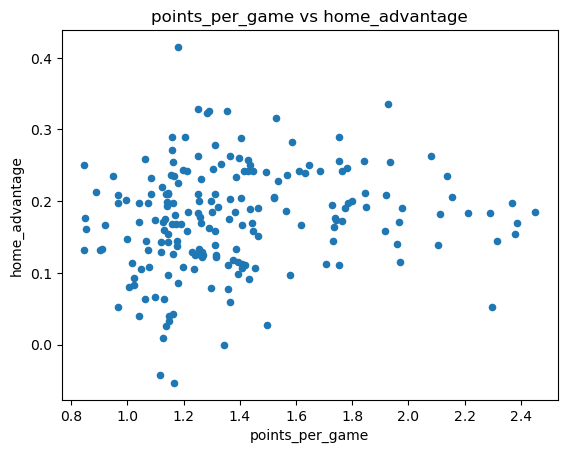

In [20]:
analysis_df_filtered.plot.scatter(x = 'points_per_game', y = 'home_advantage', title='points_per_game vs home_advantage')

### Preliminary findings
Averaging the data by club slightly increased the observed correlations. However, the relationship between team strength and home advantage remained weak, suggesting that long-term team quality alone is not a strong predictor of home advantage.

## Attacking and defensive performance

The previous analysis showed little evidence that overall team strength is associated with home advantage.

The next question is whether a team's playing characteristics are more important than its overall strength.

Specifically, we will investigate whether:
- teams that score more goals tend to have greater home advantage;
- teams that concede fewer goals tend to have greater home advantage.

In [21]:
analysis_df["goals_scored_per_game"] = analysis_df["GF"] / analysis_df["MP"]
analysis_df["goals_conceded_per_game"] = analysis_df["GA"] / analysis_df["MP"]

### Hyphothesis 

1. Teams that score more goals tend to have greater home advantage.

2. Teams that concede fewer goals tend to have greater home advantage.

In [22]:
attack_defence_df = analysis_df[
    [
        "home_advantage",
        "goals_scored_per_game",
        "goals_conceded_per_game"
    ]
]

In [23]:
attack_defence_df.corr()

,home_advantage,goals_scored_per_game,goals_conceded_per_game
home_advantage,1.000000,0.109391,-0.063811
goals_scored_per_game,0.109391,1.000000,-0.461144
goals_conceded_per_game,-0.063811,-0.461144,1.000000


<Axes: title={'center': 'goals_scored_per_game vs home_advantage'}, xlabel='goals_scored_per_game', ylabel='home_advantage'>

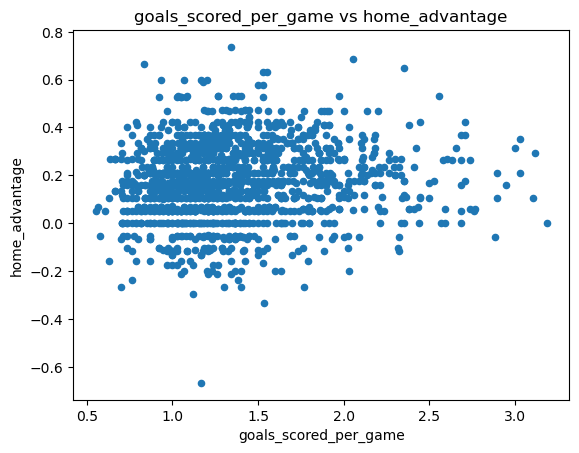

In [24]:
attack_defence_df.plot.scatter(x = 'goals_scored_per_game', y = 'home_advantage', title='goals_scored_per_game vs home_advantage')

<Axes: title={'center': 'goals_conceded_per_game vs home_advantage'}, xlabel='goals_conceded_per_game', ylabel='home_advantage'>

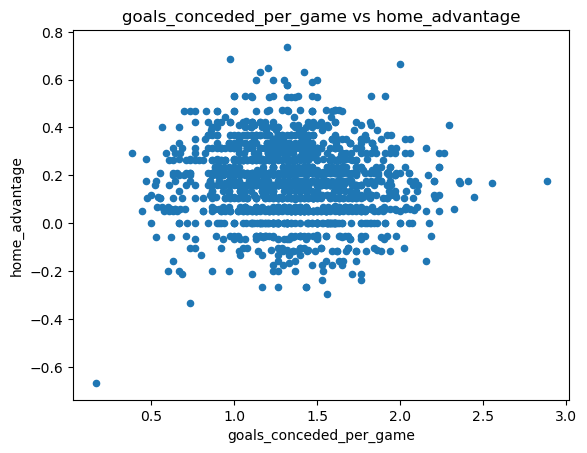

In [25]:
attack_defence_df.plot.scatter(x = 'goals_conceded_per_game', y = 'home_advantage', title='goals_conceded_per_game vs home_advantage')

### Preliminary findings

The correlation analysis again revealed only weak relationships between home advantage and both attacking and defensive performance.

Goals scored per game showed a weak positive correlation with home advantage (r = 0.11), while goals conceded per game showed a very weak negative correlation (r = -0.06). The scatter plots support these findings, as neither relationship displays a clear linear trend.

These results suggest that teams with stronger attacking or defensive performance do not consistently benefit more from playing at home. Although teams that concede fewer goals appear to have slightly higher home advantage, the observed relationship is too weak to be considered meaningful.

To verify whether season-to-season variation affects these findings, the analysis will also be repeated using club-level averages across multiple seasons.

## Club-level analysis

As in the previous section, season-level observations are averaged by club to reduce random season-to-season variation.

In [26]:
club_goal_analysis = analysis_df[
    [
        "Club",
        "home_advantage",
        "goals_scored_per_game",
        "goals_conceded_per_game"
    ]
]

In [27]:
club_goal_analysis = (
    club_goal_analysis
    .groupby("Club")
    .mean()
    .reset_index()
)

In [28]:
club_goal_analysis_filtered = club_goal_analysis[club_goal_analysis["Club"].isin(four_seasons.index)]

In [29]:
club_goal_analysis_filtered.head()

,Club,home_advantage,goals_scored_per_game,goals_conceded_per_game
1,1. FC Köln,0.039216,1.107843,1.524510
2,1. FC Nürnberg,0.129412,1.135294,1.582353
3,1. FSV Mainz 05,0.184874,1.344538,1.340336
7,ADO Den Haag,0.154412,1.345588,1.720588
8,AJ Auxerre,0.118421,1.105263,1.065789


In [30]:
club_goal_analysis_filtered.corr(numeric_only=True)

,home_advantage,goals_scored_per_game,goals_conceded_per_game
home_advantage,1.000000,0.162088,-0.079473
goals_scored_per_game,0.162088,1.000000,-0.634276
goals_conceded_per_game,-0.079473,-0.634276,1.000000


<Axes: title={'center': 'goals_scored_per_game vs home_advantage, throughout seasons'}, xlabel='goals_scored_per_game', ylabel='home_advantage'>

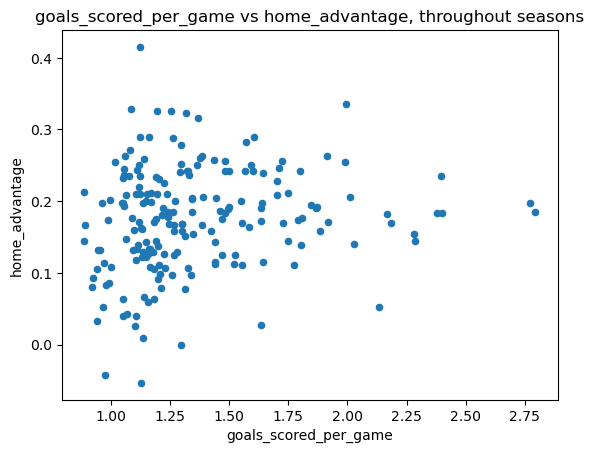

In [31]:
club_goal_analysis_filtered.plot.scatter(x = 'goals_scored_per_game', y = 'home_advantage', title='goals_scored_per_game vs home_advantage, throughout seasons')

<Axes: title={'center': 'goals_conceded_per_game vs home_advantage, throughout seasons'}, xlabel='goals_conceded_per_game', ylabel='home_advantage'>

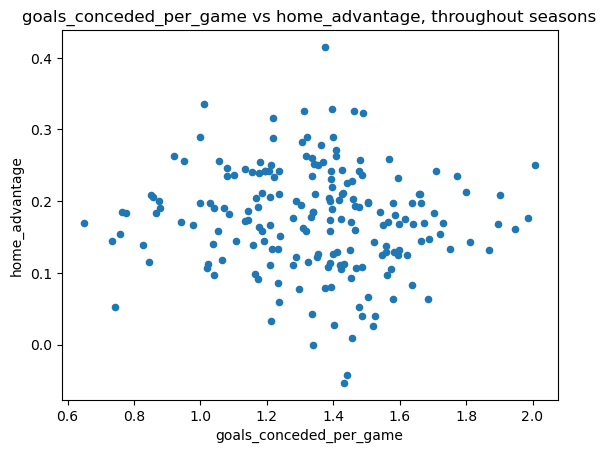

In [32]:
club_goal_analysis_filtered.plot.scatter(x = 'goals_conceded_per_game', y = 'home_advantage', title='goals_conceded_per_game vs home_advantage, throughout seasons')

### Results

After averaging statistics across multiple seasons for each club, the observed relationships remained largely unchanged.

The correlation between goals scored per game and home advantage increased only slightly (r = 0.16), while the correlation between goals conceded per game and home advantage remained very weak (r = -0.08). Scatter plots also showed no clear linear relationship between these variables.

These findings suggest that neither attacking nor defensive performance alone explains differences in home advantage. Even after reducing season-to-season variation, teams that score more goals or concede fewer goals do not consistently experience greater home advantage.

# Overall conclusions
- Team strength shows only a weak relationship with home advantage.
- This conclusion remains unchanged after averaging statistics across multiple seasons.
- Attacking performance is also only weakly associated with home advantage.
- Defensive performance shows virtually no meaningful relationship with home advantage.
- Home advantage therefore appears to be relatively independent of overall team quality and general attacking or defensive performance.
-Future work may investigate whether league characteristics or club-specific factors better explain differences in home advantage.